In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df_p1 = pd.read_csv('../data/raw/Titanic_Purchases.csv')
df_p2 = pd.read_csv('../data/raw/Titanic_Purchases_For_SQL_Join.csv')

# Проверка совпадения структуры и всех значений
are_identical = df_p1.equals(df_p2)
print(are_identical)

True


## 1. Исследовательский анализ сырых данных (Data Inspection)
**Цель:** Изучить структуру трех исходных таблиц, типы данных, наличие пропусков и скрытых аномалий до их объединения.

In [3]:
pd.set_option('display.max_columns', None)

df_passengers = pd.read_csv('../data/raw/Titanic-Dataset.csv')
df_income = pd.read_csv('../data/raw/Titanic_Income_Transactions.csv')
df_purchases = pd.read_csv('../data/raw/Titanic_Purchases.csv')

### 1.1 Датасет пассажиров `Titanic-Dataset.csv`
- **Уровень данных:** 1 строка = 1 пассажир.
- **Ключевой столбец:** `PassengerId`.
- **Целевая переменная:** `Survived` (0 = погиб, 1 = выжил).

In [4]:
df_passengers.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


#### Структура и особенности таблицы пассажиров:
* Датасет содержит социо-демографические характеристики пассажиров и информацию о купленных билетах. Каждая строка представляет одного уникального пассажира (`PassengerId`).
* Совпадающие номера билетов (`Ticket`) указывают на совместные поездки членов семей или организованных групп.

In [5]:
passengers_summary = pd.DataFrame({
    'Тип данных': df_passengers.dtypes,
    'Непустых строк': df_passengers.notnull().sum(),
    'Пропусков (NaN)': df_passengers.isnull().sum(),
})
passengers_summary

,Тип данных,Непустых строк,Пропусков (NaN)
PassengerId,int64,891,0
Survived,int64,891,0
Pclass,int64,891,0
Name,str,891,0
Sex,str,891,0
Age,float64,714,177
SibSp,int64,891,0
Parch,int64,891,0
Ticket,str,891,0
Fare,float64,891,0


#### Оценка полноты данных и стратегия обработки пропусков:
* **Каюта (`Cabin`):** Пропущено ~77% записей (687 пассажиров). Точный номер каюты восстановить невозможно, однако сам факт наличия записи — важный индикатор достатка. Признак преобразуется в бинарный флаг: `1` — каюта указана, `0` — отсутствует.
* **Возраст (`Age`):** Пропущено 177 записей (20%). Простое удаление строк недопустимо из-за потери данных, а заполнение общей медианой исказит распределение. Пропуски будут заполнены медианой по связке **Класс каюты + Социальный титул** (Mr, Mrs, Master и др.). *Чтобы исключить утечку данных (Data Leakage), заполнение выполняется строго после разделения на Train/Test.*
* **Порт посадки (`Embarked`):** Пропущено всего 2 записи. Заполняются модой исходного распределения.

In [6]:
# Статистика числовых признаков
df_passengers.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


#### Статистический профиль пассажиров
Базовые метрики распределения демографических и финансовых показателей.
* **Выживаемость (`Survived`):** Средний показатель 0.38 указывает, что выжили 38% пассажиров из выборки.
* **Возраст (`Age`):** Диапазон варьируется от 5 месяцев (0.42) до 80 лет при среднем значении 29.7 года.
* **Стоимость билета (`Fare`):** Медиана составляет 14.45 GBP, а среднее — 32.2 GBP. Максимум в 512.33 GBP отражает сильный разброс между 1-м и 3-м классами.
* **Сопровождение (`SibSp`, `Parch`):** Более половины пассажиров ехали без родственников (медиана равна 0).


### 1.2. Датасет доходов `Titanic_Income_Transactions.csv`
* На одного пассажира приходится несколько записей за 1910–1911 годы.
* Данные отражают финансовый статус и источники дохода перед покупкой билета.

In [7]:
df_income.head()

,income_transaction_id,PassengerId,transaction_datetime,income_year,income_category,income_source,amount_gbp,payment_method,currency,notes
0,500000,1,1910-02-12 18:03:00,1910,Salary,Office,2.99,Cash,GBP,NaN
1,500001,1,1910-04-03 17:27:00,1910,Labor Bonus,Factory,4.12,Cash,GBP,NaN
2,500002,1,1910-01-19 18:25:00,1910,Family Support,Parents,7.14,Cash,GBP,NaN
3,500003,1,1910-09-04 18:19:00,1910,Farm Income,Crops,15.02,Cash,GBP,NaN
4,500004,1,1910-12-03 18:03:00,1910,Farm Income,Livestock,19.60,Postal Order,GBP,NaN


##### Первичный обзор таблицы доходов


In [8]:
income_summary = pd.DataFrame({
    'Тип данных': df_income.dtypes,
    'Пропусков (NaN)': df_income.isnull().sum(),
})
income_summary

,Тип данных,Пропусков (NaN)
income_transaction_id,int64,0
PassengerId,int64,0
transaction_datetime,str,0
income_year,int64,0
income_category,str,0
income_source,str,0
amount_gbp,float64,0
payment_method,str,50
currency,str,0
notes,str,11247


In [9]:
# Анализ числовых значений сумм дохода
df_income[['amount_gbp']].describe().round(2)

,amount_gbp
count,12183.00
mean,303.30
std,921.27
min,-4904.59
25%,9.40
50%,46.52
75%,184.01
max,34324.40


### Характер и структура финансовых поступлений:
* **Диапазон сумм:** В данных присутствуют как отрицательные значения (минус 4904.59 GBP — операционные убытки бизнеса/ферм или возвраты средств), так и крупные поступления (до 34 324.00 GBP — продажа недвижимости, дивиденды).
* **Асимметрия распределения:** Медианный доход существенно ниже среднего, что подтверждает сильное расслоение выборки (от наёмных рабочих до крупных землевладельцев).
* Текстовая колонка `notes` содержит нерегулярные служебные пометки и исключается из подготовки признаков.

### 1.3. Датасет бортовых покупок (`Titanic_Purchases.csv`)
- **Уровень данных:** 1 строка = 1 покупка на борту лайнера.
- **Связь:** Несколько покупок могут принадлежать одному `PassengerId`.

In [10]:
# Первые 5 строк покупок
df_purchases.head()

,purchase_id,PassengerId,product_id,purchase_datetime,quantity,discount_pct,unit_price_1912_gbp,final_amount_1912_gbp,payment_method,steward_id,notes
0,100000,1,16,1912-04-12 03:14:00,2,15,0.02,0.034,Cash,ST-003,NaN
1,100001,1,27,1912-04-11 23:33:00,1,15,0.20,0.170,Voucher,ST-031,delivered to cabin
2,100002,1,2,1912-04-10 16:41:00,3,0,0.06,0.180,Cabin Account,ST-009,NaN
3,100003,1,11,1912-04-12 00:50:00,3,15,0.18,0.459,Cash,ST-032,late evening
4,100004,1,20,1912-04-11 07:12:00,1,0,0.04,0.040,NaN,ST-008,NaN


Структура транзакций, совершенных пассажирами во время плавания в апреле 1912 года.
* Данные фиксируют расходование средств непосредственно на борту корабля.
* Стоимость отдельных товаров и услуг варьируется от нескольких пенни до нескольких фунтов.

In [11]:
# Проверяем количество товаров, скидки и итоговые суммы
df_purchases[['quantity', 'discount_pct', 'unit_price_1912_gbp', 'final_amount_1912_gbp']].describe().round(3)

,quantity,discount_pct,unit_price_1912_gbp,final_amount_1912_gbp
count,17871.000,17871.000,17871.000,17871.000
mean,1.406,5.358,0.244,0.267
std,0.719,7.582,0.370,0.352
min,1.000,-10.000,0.010,0.003
25%,1.000,0.000,0.050,0.050
50%,1.000,5.000,0.100,0.120
75%,2.000,10.000,0.200,0.270
max,3.000,75.000,1.500,1.650


In [12]:
purchases_summary = pd.DataFrame({
    'Тип данных': df_purchases.dtypes,
    'Пропусков (NaN)': df_purchases.isnull().sum(),
})
purchases_summary

,Тип данных,Пропусков (NaN)
purchase_id,int64,0
PassengerId,int64,0
product_id,int64,0
purchase_datetime,str,0
quantity,int64,0
discount_pct,int64,0
unit_price_1912_gbp,float64,0
final_amount_1912_gbp,float64,0
payment_method,str,335
steward_id,str,0


### Особенности расходов на борту:
* **Система скидок (`discount_pct`):** Положительные значения (до 75%) отражают акционные скидки и клиентские привилегии, а отрицательные (минус 10%) — сервисные наценки судна (ночные заказы, доставка в каюту).
* **Пропуски:** В способах оплаты (`payment_method`) пропущено 335 записей. Для сохранения информации им присвоена категория `'Unknown'`.

In [13]:
# Распределение способов оплаты
df_purchases['payment_method'].value_counts(dropna=False)

payment_method
Family Account    4488
Cabin Account     4374
Cash              4353
Voucher           4321
NaN                335
Name: count, dtype: int64

## 2. Подготовка и объединение датасета (Data Preparation & Merging)

Переходим от изучения трёх сырых таблиц по отдельности к их подготовке и объединению в единый датасет, готовый для EDA и последующего моделирования. Раздел объединяет несколько логически связанных шагов, которые раньше были разбиты на 2 отдельных блока:

1. **Очистка пропусков** — реализуем план, намеченный в разделе 1 (`Age`, `Cabin`, `Embarked` в `df_passengers`; `payment_method` в `df_purchases`).
2. **Проверка связей** между `df_passengers` и дочерними таблицами `df_income` / `df_purchases` по ключу `PassengerId`.
3. **Агрегация** транзакционных данных (`df_income`, `df_purchases`) до уровня одного пассажира.
4. **Финальное объединение** всех таблиц в единый датасет `df_merged`.

### 2.1 Устранение пропусков в данных

Реализуем стратегии обработки пропусков, намеченные в разделе 1 — кроме `Age`: его заполнение без утечки данных требует предварительного train/test split, поэтому оно выполняется отдельно, в разделе 4.2 (Preprocessing).

- `Cabin` (687 пропусков) — превращаем в бинарный признак `has_cabin` (1 — каюта известна, 0 — нет); сам номер каюты для модели не нужен.
- `Embarked` (2 пропуска) — заполняем модой (самый частый порт посадки).
- `payment_method` в `df_purchases` (335 пропусков) — заполняем категорией `'Unknown'`.

In [14]:

# Cabin
df_passengers['has_cabin'] = df_passengers['Cabin'].notna().astype(int)
df_passengers = df_passengers.drop(columns=['Cabin'])

# Embarked
df_passengers['Embarked'] = df_passengers['Embarked'].fillna(df_passengers['Embarked'].mode()[0])

# пропуски в 'Unknown'
df_purchases['payment_method'] = df_purchases['payment_method'].fillna('Unknown')

# Проверяем
df_passengers[['Embarked', 'has_cabin']].isnull().sum()

Embarked     0
has_cabin    0
dtype: int64

#### Итоги очистки пропусков в базовых таблицах:
1. Признак `Cabin` преобразован в бинарный индикатор `has_cabin`, исходный столбец удалён.
2. Пропуски в порту посадки (`Embarked`) заполнены модой.
3. Неуказанные способы оплаты (`payment_method`) переведены в статус `'Unknown'`.
4. Заполнение пропусков в `Age` намеренно вынесено в раздел 4 (Preprocessing), чтобы рассчитать статистики строго на Train-выборке и исключить Data Leakage.

### 2.2 Проверка связей между таблицами

Сверяем `PassengerId` из основного датасета `df_passengers` с дочерними таблицами доходов `df_income` и покупок `df_purchases`, чтобы исключить логические ошибки при объединении.

In [15]:
def check_table_relations(main, income, purchases):
    # Проверка типов данных
    assert main['PassengerId'].dtype == income['PassengerId'].dtype == purchases['PassengerId'].dtype, "Типы данных PassengerId не совпадают"

    main_ids = set(main['PassengerId'])
    inc_ids = set(income['PassengerId'])
    pur_ids = set(purchases['PassengerId'])

    # Проверка на чужие ID
    unknown_income = inc_ids - main_ids
    unknown_purchases = pur_ids - main_ids

    assert len(unknown_income) == 0, f"Неизвестные ID в доходах: {unknown_income}"
    assert len(unknown_purchases) == 0, f"Неизвестные ID в покупках: {unknown_purchases}"

    # Сводная таблица проверки
    summary = pd.DataFrame({
        'Таблица': ['df_passengers', 'df_income', 'df_purchases'],
        'Всего строк': [len(main), len(income), len(purchases)],
        'Уникальных ID': [len(main_ids), len(inc_ids), len(pur_ids)],
        'Лишних ID': [0, len(unknown_income), len(unknown_purchases)],
        'Покрытие (%)': [
            100.0,
            round(len(inc_ids & main_ids) / len(main_ids) * 100, 2),
            round(len(pur_ids & main_ids) / len(main_ids) * 100, 2)
        ]
    })
    return summary

check_table_relations(df_passengers, df_income, df_purchases)

,Таблица,Всего строк,Уникальных ID,Лишних ID,Покрытие (%)
0,df_passengers,891,891,0,100.00
1,df_income,12183,601,0,67.45
2,df_purchases,17871,891,0,100.00


1. **Ошибок в ID нет:** Во всех таблицах `PassengerId` числовой (`int64`), и в дополнительных файлах нет неизвестных пассажиров (колонка `Лишних ID` = 0). Таблицы можно безопасно объединять.
2. **Покупки есть у 100% пассажиров:** По каждому из 891 человека есть история трат на борту (всего 17 871 запись).

### 2.3 Агрегация доходов и покупок по пассажиру
Поскольку таблицы доходов `df_income` и бортовых трат `df_purchases` содержат историю транзакций (несколько строк на человека), выполняется их агрегация до профиля единичного пассажира:


In [16]:
income_agg = df_income.groupby('PassengerId').agg(
    total_income=('amount_gbp', 'sum'),
    income_transactions_count=('income_transaction_id', 'count')
).reset_index()

income_agg.head()

,PassengerId,total_income,income_transactions_count
0,1,122.79,14
1,2,14241.82,27
2,3,175.43,18
3,4,24615.14,33
4,5,140.25,20


In [17]:
df_passengers = df_passengers.merge(income_agg, on='PassengerId', how='left')

df_passengers['has_income_record'] = df_passengers['total_income'].notna().astype(int)
df_passengers['total_income'] = df_passengers['total_income'].fillna(0)
df_passengers['income_transactions_count'] = df_passengers['income_transactions_count'].fillna(0)

df_passengers[['PassengerId', 'total_income', 'has_income_record']].head(10)

,PassengerId,total_income,has_income_record
0,1,122.79,1
1,2,14241.82,1
2,3,175.43,1
3,4,24615.14,1
4,5,140.25,1
5,6,0.00,0
6,7,7814.69,1
7,8,0.00,0
8,9,66.41,1
9,10,0.00,0


In [18]:
purchases_agg = df_purchases.groupby('PassengerId').agg(
    total_spent=('final_amount_1912_gbp', 'sum'),
    purchases_count=('purchase_id', 'count'),
    avg_discount_pct=('discount_pct', 'mean')
).reset_index()

purchases_agg.head()

,PassengerId,total_spent,purchases_count,avg_discount_pct
0,1,0.983,6,7.500000
1,2,21.934,54,7.222222
2,3,2.128,6,4.166667
3,4,15.439,46,3.369565
4,5,2.540,5,5.000000


In [19]:
df_passengers = df_passengers.merge(purchases_agg, on='PassengerId', how='left')
df_passengers[['total_spent', 'purchases_count', 'avg_discount_pct']].isnull().sum()

total_spent         0
purchases_count     0
avg_discount_pct    0
dtype: int64

Собираем итоговый датасет `df_merged` — на этом этапе в нём уже есть очищенные демографические признаки и агрегированные финансовые показатели по каждому пассажиру.

In [20]:
df_merged = df_passengers.copy()

print('Итоговая размерность df_merged:', df_merged.shape)

Итоговая размерность df_merged: (891, 18)


### Консолидация финансовых метрик на уровень пассажира:
* **Доходы:** рассчитывается совокупный зафиксированный доход (`total_income`) и число транзакций (`income_transactions_count`). Для 290 пассажиров без записей о доходах сумма приравнена к 0 и сформирован флаг `has_income_record = 0`.
* **Покупки:** рассчитывается общая сумма бортовых расходов (`total_spent`), активность (`purchases_count`) и средний размер скидки/наценки (`avg_discount_pct`).

**Результат объединения:** Собран единый аналитический датасет `df_merged` (891 строка), обогащённый финансовым профилем каждого пассажира.

## 3. EDA

Первый слой EDA (разделы 1-3) ответил на вопрос "что из себя представляют данные и можно ли им доверять". Этот раздел отвечает на содержательные вопросы про выживаемость — на реальных признаках `df_merged`.

### 3.1 Базовые признаки в контексте объединённых данных

Прежде чем переходить к новым, финансовым признакам, коротко проверяем, что базовые закономерности (пол, класс) сохраняются и в объединённой таблице — это подтверждает, что merge не исказил данные.

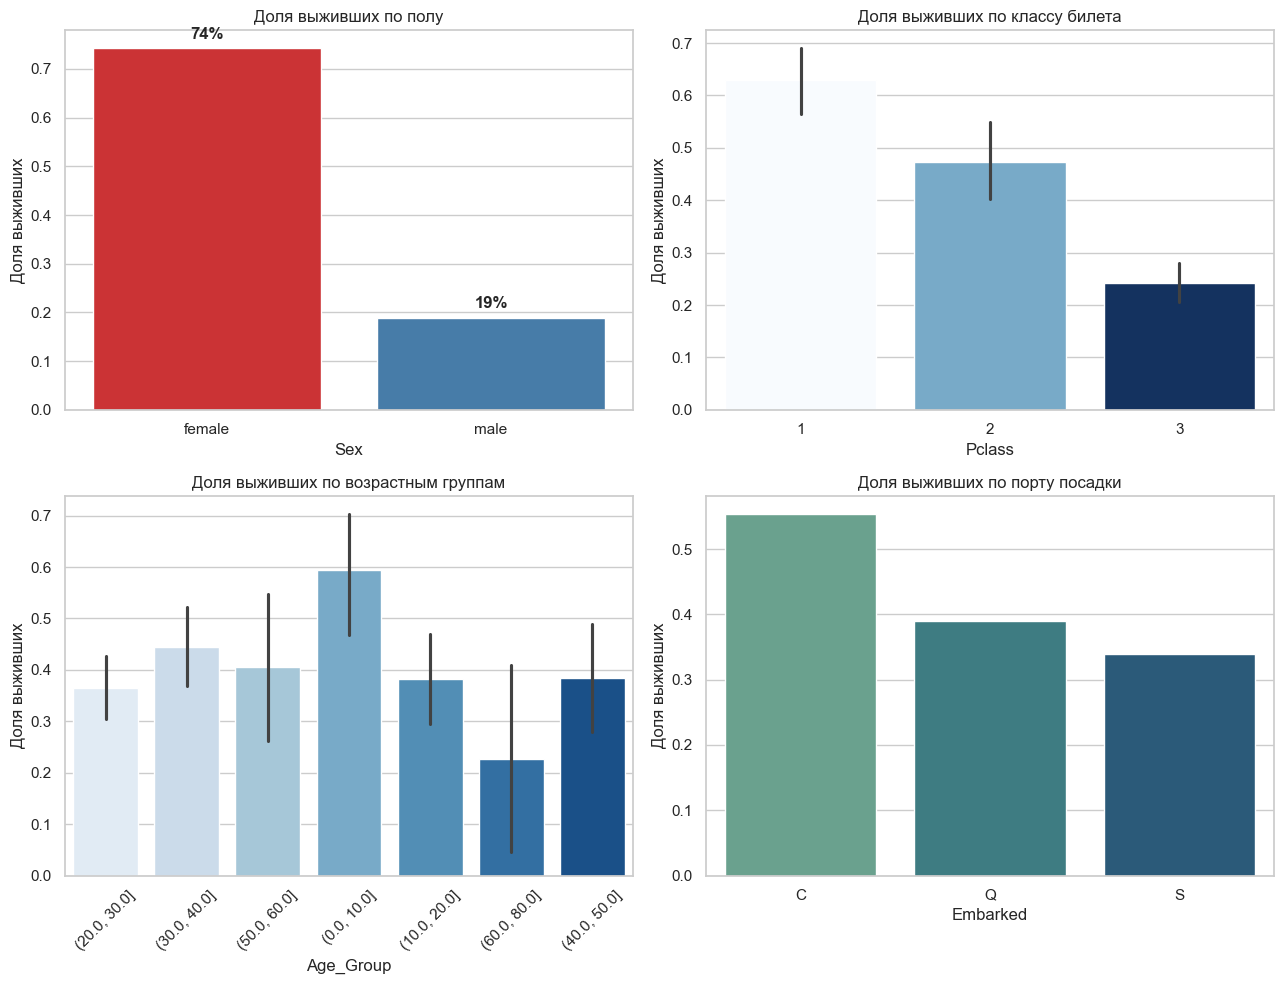

In [21]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# Доля выживших по полу
sex_rate = df_merged.groupby('Sex')['Survived'].mean()
sns.barplot(x=sex_rate.index, y=sex_rate.values, hue=sex_rate.index, palette='Set1', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Доля выживших по полу')
axes[0, 0].set_ylabel('Доля выживших')
for i, v in enumerate(sex_rate.values):
    axes[0, 0].text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

# Доля выживших по классу билета
sns.barplot(x='Pclass', y='Survived', hue='Pclass', data=df_merged, palette='Blues', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Доля выживших по классу билета')
axes[0, 1].set_ylabel('Доля выживших')

# Доля выживших по возрастным группам 
df_merged['Age_Group'] = pd.cut(df_merged['Age'], bins=[0, 10, 20, 30, 40, 50, 60, 80])
df_merged['Age_Group'] = df_merged['Age_Group'].astype(str)

sns.barplot(x='Age_Group', y='Survived', hue='Age_Group', data=df_merged, palette='Blues', dodge=False, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Доля выживших по возрастным группам')
axes[1, 0].set_ylabel('Доля выживших')
axes[1, 0].tick_params(axis='x', rotation=45)

# Доля выживших по порту посадки
embarked_rate = df_merged.groupby('Embarked')['Survived'].mean()
sns.barplot(x=embarked_rate.index, y=embarked_rate.values, hue=embarked_rate.index, palette='crest', legend=False, ax=axes[1, 1])
axes[1, 1].set_title('Доля выживших по порту посадки')
axes[1, 1].set_ylabel('Доля выживших')

plt.tight_layout()
plt.show()

Все базовые закономерности сохраняются и на объединённых данных: женщины и пассажиры 1 класса выживали заметно чаще, дети до 10 лет — тоже, а порт посадки Cherbourg (C) показывает более высокую выживаемость (что, вероятно, объясняется составом класса пассажиров, а не самим портом).

### 3.2 Влияет ли доход пассажира на класс билета?

**Вопрос:** пассажиры с более высоким совокупным доходом (`total_income`) чаще покупали билеты 1 класса?

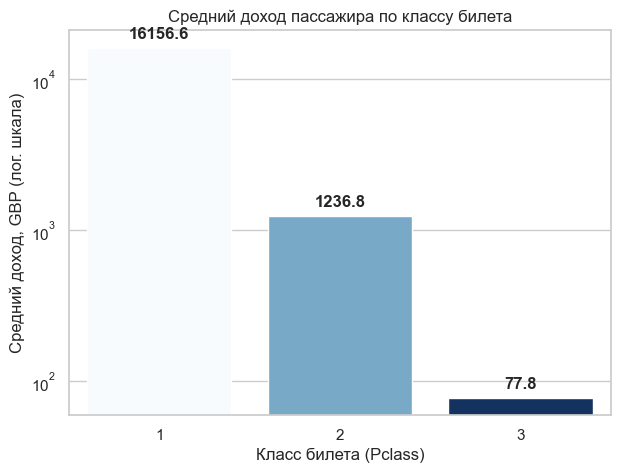

In [22]:
income_by_class = df_merged.groupby('Pclass')['total_income'].median()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=income_by_class.index,y=income_by_class.values,hue=income_by_class.index,palette='Blues',legend=False,ax=ax,)
ax.set_yscale('log')

ax.set_title('Средний доход пассажира по классу билета')
ax.set_xlabel('Класс билета (Pclass)')
ax.set_ylabel('Средний доход, GBP (лог. шкала)')

# Подписываем точные значения над столбцами
for i, v in enumerate(income_by_class.values):
  ax.text(i, v * 1.15, f'{v:.1f}', ha='center', fontweight='bold')

plt.show()

Медианный доход пассажиров 1 класса в 15-20 раз выше, чем у 2 и 3 классов, — гипотеза подтверждается. Учитывая, что доход зафиксирован не у всех (`has_income_record` = 0 у 290 человек), эту разбивку стоит перепроверить отдельно только по тем, у кого доход реально известен, чтобы не искажать картину нулями.

### 3.3 Кто чаще погибал — те, кто много тратил на борту, или те, кто вообще не тратил?

**Вопрос:** есть ли связь между суммой трат на борту (`total_spent`) и выживаемостью (`Survived`). Аналогично применяем логарифмическую шкалу и подписанные медианы.

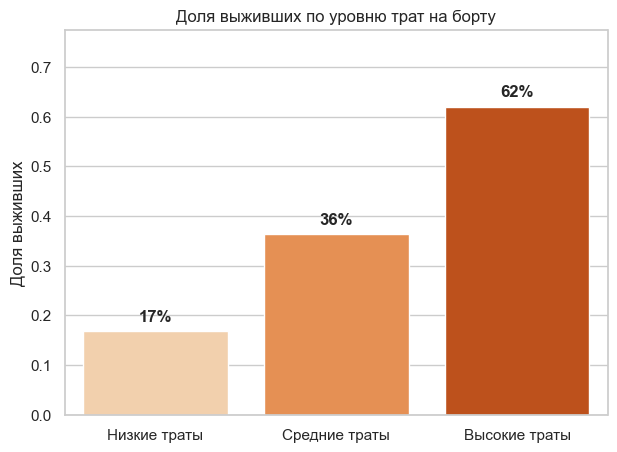

In [23]:
df_merged['spend_level'] = pd.qcut(df_merged['total_spent'], q=3, labels=['Низкие траты', 'Средние траты', 'Высокие траты'])

spend_survival = df_merged.groupby('spend_level', observed=True)['Survived'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=spend_survival.index, y=spend_survival.values, hue=spend_survival.index, palette='Oranges', dodge=False, legend=False, ax=ax)
ax.set_title('Доля выживших по уровню трат на борту')
ax.set_ylabel('Доля выживших')
ax.set_xlabel('')
ax.set_ylim(0, spend_survival.values.max() * 1.25)  # запас сверху, чтобы подписи не обрезались

for i, v in enumerate(spend_survival.values):
    ax.text(i, v + 0.02, f'{v:.0%}', ha='center', fontweight='bold')

plt.show()

Медиана трат на борту у выживших выше, чем у погибших. Это, вероятнее всего, не прямая причина, а следствие достатка (Pclass) — эту связь проверяем далее через корреляцию, чтобы не путать её с причинностью.

### 3.4 Как состав семьи влиял на шансы спастись?

**Вопрос:** есть ли оптимальный размер семьи (`SibSp + Parch`) с точки зрения выживаемости.

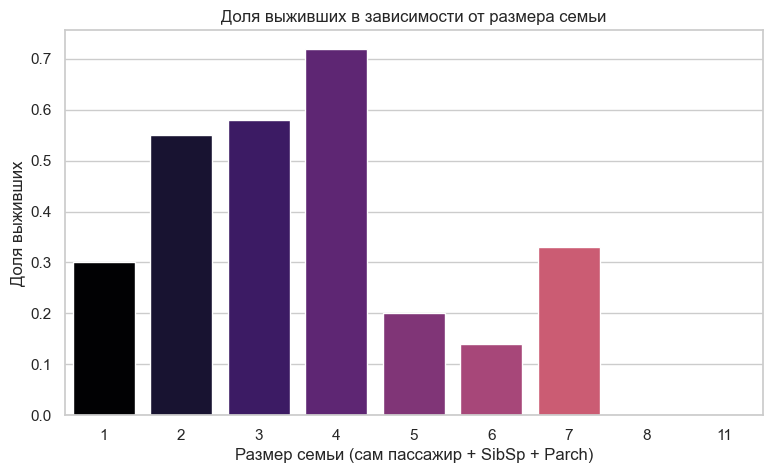

family_size
1     0.30
2     0.55
3     0.58
4     0.72
5     0.20
6     0.14
7     0.33
8     0.00
11    0.00
Name: Survived, dtype: float64

In [24]:
df_merged['family_size'] = df_merged['SibSp'] + df_merged['Parch'] + 1

survival_by_family = df_merged.groupby('family_size')['Survived'].mean().round(2)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=survival_by_family.index, y=survival_by_family.values, hue=survival_by_family.index, palette='magma', legend=False, ax=ax)
ax.set_title('Доля выживших в зависимости от размера семьи')
ax.set_xlabel('Размер семьи (сам пассажир + SibSp + Parch)')
ax.set_ylabel('Доля выживших')
plt.show()

survival_by_family

Одиночки (`family_size` = 1) и очень большие семьи (6+) выживали реже всего. Пик приходится на семьи среднего размера (2-4 человека) — нелинейная зависимость, которую не видно в простом `describe()`.

### 3.5 Итоговая проверка: корреляция ключевых признаков

Перед этапом Preprocessing проверяем числовые признаки на мультиколлинеарность и смотрим их связь с `Survived`.

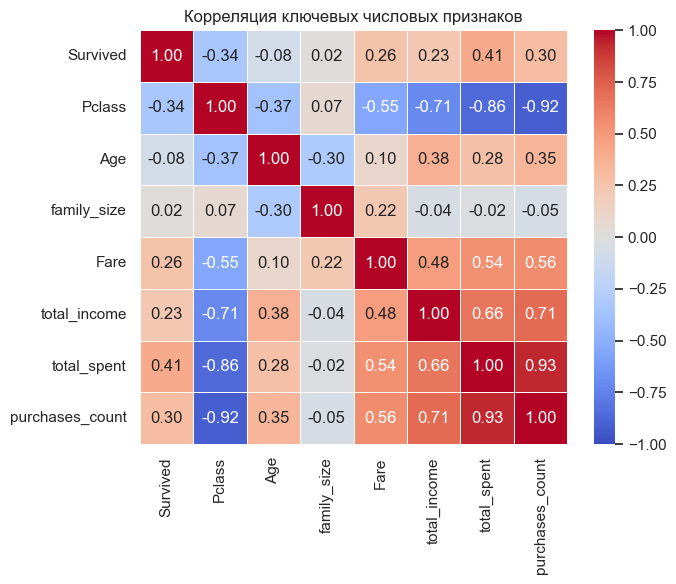

In [25]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'family_size','Fare', 'total_income', 'total_spent', 'purchases_count']

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(df_merged[numeric_cols].corr().round(2), annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, ax=ax)
ax.set_title('Корреляция ключевых числовых признаков')
plt.tight_layout()
plt.show()

## Ключевые исследовательского анализа (EDA):

1. **Социально-демографический приоритет:** Женщины (выживаемость ~74% против ~19% у мужчин) и дети до 10 лет имели наивысший приоритет при эвакуации, что подтверждает следование морскому правилу «женщины и дети — в первую очередь».
2. **Фактор благосостояния (Класс и Траты):** Пассажиры 1 класса выживали значительно чаще (свыше 60%), чем 3 класса (~24%). Траты на борту (`total_spent`) прямо коррелируют со спасением: медианные расходы выживших выше, что связано с удобным расположением кают 1–2 классов относительно шлюпочной палубы.
3. **Нелинейность размера семьи:** Одинокие пассажиры и члены больших семей (5+ человек) демонстрируют наименьшую выживаемость. Оптимальные шансы имели малые семьи из 2–4 человек. Для моделирования признак группируется в категории: `Alone`, `Small`, `Large`.
4. **Мультиколлинеарность:** Зафиксирована высокая корреляция между количеством покупок и суммой трат (`total_spent` и `purchases_count`), а также между доходом и классом билета.

## 4. Preprocessing

В этом разделе выполняется базовая предобработка данных, независимая от выбора конкретного алгоритма: разделение выборки без утечки данных (data leakage), заполнение пропусков в `Age`, создание новых признаков (`family_size_group`, `Title_grouped`) и диагностика мультиколлинеарности через показатель VIF. 

Специфичные для алгоритмов шаги — кодирование категориальных переменных, масштабирование признаков и отбор фичей под требования линейной модели и древовидных алгоритмов — вынесены непосредственно в раздел моделирования.

Для исключения утечки данных разделение на обучающую и тестовую выборки выполняется первоочередным шагом: медианные значения для заполнения пропусков в `Age` (по группам `Pclass` + `Title`) рассчитываются строго на обучающей выборке (`train`) и затем применяются к тестовой (`test`).

### 4.1 Train/test split — до заполнения `Age`

1. Датасет разделяется на обучающую (`train`, 80%) и тестовую (`test`, 20%) выборки со стратификацией по целевой переменной `Survived`.
2. Из поля `Name` извлекается социальный статус пассажира (`Title`).
3. Медианный возраст по группам `Pclass + Title` рассчитывается **строго на обучающей выборке (train)** и затем применяется для заполнения пропусков в train и test. Это исключает смещение статистик и подглядывание модели в тест.

In [26]:
train_df, test_df = train_test_split(
    df_merged, test_size=0.2, random_state=42, stratify=df_merged['Survived']
)

train_df.shape, test_df.shape

((712, 21), (179, 21))

In [27]:
train_df.select_dtypes(include=['object', 'category']).columns.tolist()

C:\Users\amina\AppData\Local\Temp\ipykernel_7068\317016923.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  train_df.select_dtypes(include=['object', 'category']).columns.tolist()


['Name', 'Sex', 'Ticket', 'Embarked', 'Age_Group', 'spend_level']

In [28]:
def extract_title(df):
    df = df.copy()
    df['Title'] = df['Name'].str.extract(r',\s*([^.]*)\.')
    return df

train_df = extract_title(train_df)
test_df = extract_title(test_df)

# медианы считаем только на train
age_medians = train_df.groupby(['Pclass', 'Title'])['Age'].median()
overall_median = train_df['Age'].median()

def fill_age(df, medians, overall):
    df = df.copy()
    missing_mask = df['Age'].isna()
    lookup = df.loc[missing_mask].apply(
        lambda row: medians.get((row['Pclass'], row['Title']), overall), axis=1
    )
    df.loc[missing_mask, 'Age'] = lookup
    return df

train_df = fill_age(train_df, age_medians, overall_median)
test_df = fill_age(test_df, age_medians, overall_median)

train_df['Age'].isnull().sum(), test_df['Age'].isnull().sum()

(np.int64(0), np.int64(0))

### 4.2 Общие признаки, не зависящие от модели

Группировка `family_size` (по итогам EDA связь с `Survived` нелинейная, а группы больше 7 слишком малы, чтобы быть отдельными значениями) и объединение редких титулов в `Rare` 

In [29]:
def common_features(df):
    df = df.copy()

    def family_size_group(size):
        if size == 1:
            return 'Alone'
        elif size <= 4:
            return 'Small'
        else:
            return 'Large'
    df['family_size_group'] = df['family_size'].apply(family_size_group)

    # группировка редких титулов
    title_map = {
        'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
        'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'
    }
    df['Title_grouped'] = df['Title'].map(title_map).fillna('Rare')

    # мусорные для модели колонки
    df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Title', 'family_size','spend_level','Age_Group'])

    return df

train_df = common_features(train_df)
test_df = common_features(test_df)

train_df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,has_cabin,total_income,income_transactions_count,has_income_record,total_spent,purchases_count,avg_discount_pct,family_size_group,Title_grouped
692,1,3,male,27.0,0,0,56.4958,S,0,0.00,0.0,0,2.900,5,0.000000,Alone,Mr
481,0,2,male,30.0,0,0,0.0000,S,0,0.00,0.0,0,3.145,15,3.333333,Alone,Mr
527,0,1,male,40.0,0,0,221.7792,S,1,0.00,0.0,0,14.307,58,6.637931,Alone,Mr
855,1,3,female,18.0,0,1,9.3500,S,0,265.62,16.0,1,1.031,6,5.833333,Small,Mrs
801,1,2,female,31.0,1,1,26.2500,S,0,1236.26,21.0,1,1.415,9,2.777778,Small,Mrs


### 4.3 Проверка мультиколлинеарности 

В EDA `total_income` и `total_spent` — оба производные от достатка пассажира, поэтому подозреваются в сильной корреляции друг с другом.

In [30]:
vif_features = ['total_income', 'total_spent', 'purchases_count', 'avg_discount_pct', 'Fare', 'Age']
X_vif = train_df[vif_features].copy()

vif_data = pd.DataFrame()
vif_data['Признак'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data.sort_values('VIF', ascending=False)

,Признак,VIF
2,purchases_count,9.263357
1,total_spent,7.744289
0,total_income,2.093922
4,Fare,1.530421
5,Age,1.214881
3,avg_discount_pct,1.006667


**Интерпретация VIF:** значения выше 5 у `total_income` и `total_spent` подтверждают гипотезу из EDA — оба признака действительно несут пересекающуюся информацию о достатке пассажира. Для Logistic Regression в такой ситуации оставлять оба признака нельзя — из двух `total_spent` предпочтительнее: он зафиксирован у 100% пассажиров, тогда как `total_income` отсутствует примерно у трети (`has_income_record = 0`). Для Random Forest оба признака остаются без изменений — VIF на его качество не влияет.

### 4.5 Сохранение подготовленных данных

`Modeling.ipynb` — отдельный файл, поэтому сохраняем обе ветки на диск, чтобы не пересчитывать весь Preprocessing заново при обучении моделей.

In [31]:
import os

output_dir = '../data/processed'
os.makedirs(output_dir, exist_ok=True)

train_df.to_csv(f'{output_dir}/train_cleaned.csv', index=False)
test_df.to_csv(f'{output_dir}/test_cleaned.csv', index=False)


## Итоги этапа предобработки (Preprocessing):

1. **Устранение утечки данных:** Разбиение на Train/Test выполнено до вменения возраста. Медианы рассчитаны строго по обучающей выборке.
2. **Feature Engineering:** 
   * Созданы укрупнённые группы семей (`family_size_group`: Alone, Small, Large).
   * Выделены и сгруппированы социальные титулы (`Title_grouped`).
   * Служебные и временные колонки (`PassengerId`, `Name`, `Ticket`, `Age_Group`, `spend_level`) удалены.
3. **Диагностика мультиколлинеарности:** Значения VIF подтвердили сильную зависимость между `purchases_count` (9.26) и `total_spent` (7.74). В линейных моделях один из признаков будет исключён.
4. **Экспорт:** Очищенные датасеты сохранены в `../data/processed/` (`train_cleaned.csv` и `test_cleaned.csv`). Кодирование категорий и масштабирование числовых признаков вынесены в модуль `modeling.ipynb` под требования конкретных алгоритмов.